In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=[10, 15, 20], n_features=2, centers=[[-1, -1], [0, 1], [1, 0]])

X, y

(array([[-1.57843393e+00,  8.90352163e-01],
        [ 2.18211513e+00,  5.45317571e-02],
        [ 4.35386483e-01,  1.43097334e+00],
        [-1.86018016e+00, -1.92360307e+00],
        [-2.77110883e-01, -4.50289511e-01],
        [-7.34441810e-02,  5.14614197e-01],
        [ 7.23189180e-01,  1.45368358e+00],
        [-8.92648658e-01, -3.56154732e-01],
        [ 8.13688115e-02, -1.73959582e-01],
        [-3.45127622e-01,  4.94861511e-01],
        [ 3.35140809e-01,  2.87708441e+00],
        [-1.51604830e+00,  6.63229518e-01],
        [ 7.00125364e-01,  3.30597302e-01],
        [ 4.42580631e+00,  4.31512741e-01],
        [-7.23809417e-01, -3.34262330e+00],
        [-1.32788912e-02,  5.06678628e-01],
        [ 2.90930095e-01,  2.04618170e-01],
        [ 2.79002493e-01, -1.81271860e+00],
        [ 3.39335205e+00, -7.29652170e-01],
        [-2.34543361e+00, -2.12568321e-01],
        [-2.83942797e-01,  7.59500541e-01],
        [ 9.64490495e-01,  4.33711999e-01],
        [-4.89240282e-01,  9.367

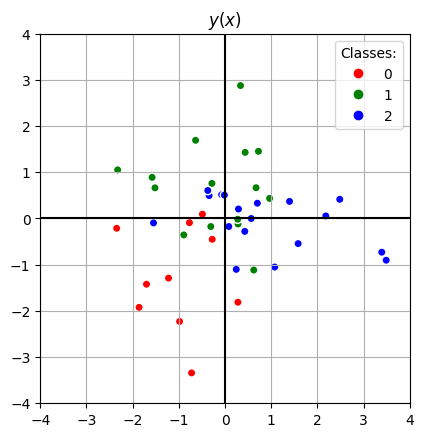

In [3]:
from  matplotlib.colors import ListedColormap
rgb_map = ListedColormap(('r', 'g', 'b'))

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.legend(*plt.scatter(X[:, 0], X[:, 1], c=y, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.title('$y(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()

In [11]:
class SoftVoting:
    
    def __init__(self, base_learners):
        self.base_learners = base_learners
        self.classes = None
        
    def __repr__(self):
        return f'SoftVoting(base_learners={repr(self.base_learners)})'
        
    def fit(self,X, y):
        self.classes = np.unique(y)
        for base_learner in self.base_learners:
            base_learner.fit(X,y)
        return self

    def predict_proba(self,X):
        proba = np.zeros((X.shape[0],len(self.classes)))
        for base_learner in self.base_learners:
            proba += base_learner.predict_proba(X)
        proba /= len(self.base_learners)
        return proba

    def predict(self, X):
        yhat = self.classes[np.argmax(self.predict_proba(X), axis=1)]
        return yhat



In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

my_voter = SoftVoting([LogisticRegression(),DecisionTreeClassifier(max_depth=3)])
my_voter

SoftVoting(base_learners=[LogisticRegression(), DecisionTreeClassifier(max_depth=3)])

In [13]:
my_voter.fit(X,y)
my_voter

SoftVoting(base_learners=[LogisticRegression(), DecisionTreeClassifier(max_depth=3)])

In [14]:
yhat = my_voter.predict(X)
yhat

array([1, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 0, 2, 2, 0, 2, 0, 1, 2,
       0, 0, 0, 1, 0, 2, 0, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 2, 1, 2,
       2])

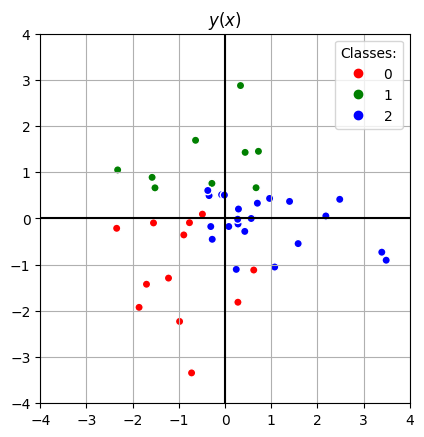

In [15]:
from  matplotlib.colors import ListedColormap
rgb_map = ListedColormap(('r', 'g', 'b'))

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.legend(*plt.scatter(X[:, 0], X[:, 1], c=yhat, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.title('$y(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()

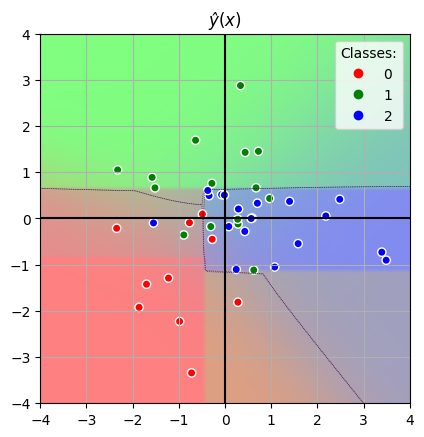

In [16]:
xx1, xx2 = np.meshgrid(np.linspace(-4.0, 4.0, 81), np.linspace(-4.0, 4.0, 81))
XX = np.array([xx1.ravel(), xx2.ravel()]).T
yy = my_voter.predict_proba(XX).reshape(xx1.shape + (3, ))

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.imshow(yy, extent=(-4.0, 4.0, -4.0, 4.0), origin='lower', interpolation='bilinear', alpha=0.5)
for z in range(yy.shape[2]):
    plt.contour(xx1, xx2, yy[:, :, z] / (1.0 - yy.min(axis=2)), [0.5], linewidths=0.5, linestyles='dotted')
plt.legend(*plt.scatter(X[:, 0], X[:, 1], c=y, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.title('$ŷ(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()